In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import load_model
import glob
import random

# Налаштування шляхів
BASE_DIR = 'dataset'                  # Де лежать оригінальні фото
CROPPED_DIR = 'dataset_cropped'       # Куди збережемо вирізані обличчя
IMG_SIZE = 160                        # Розмір входу для MobileNetV2
BATCH_SIZE = 32
EPOCHS = 20

In [17]:
# Завантажуємо детектор облич
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def process_dataset_split(split_name):
    input_path = os.path.join(BASE_DIR, split_name)
    output_path = os.path.join(CROPPED_DIR, split_name)
    
    if not os.path.exists(input_path):
        print(f"Папки {input_path} не існує.")
        return

    # Проходимо по папках людей
    for person_name in os.listdir(input_path):
        person_in_dir = os.path.join(input_path, person_name)
        person_out_dir = os.path.join(output_path, person_name)
        
        if not os.path.isdir(person_in_dir):
            continue
            
        os.makedirs(person_out_dir, exist_ok=True)
        
        # Обробляємо фото
        files = glob.glob(os.path.join(person_in_dir, "*.*"))
        count = 0
        
        for img_file in files:
            img = cv2.imread(img_file)
            if img is None: continue
            
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, 1.1, 5)
            
            for i, (x, y, w, h) in enumerate(faces):
                # Додаємо трохи рамок (padding)
                p = 10
                x1, y1 = max(0, x-p), max(0, y-p)
                x2, y2 = min(img.shape[1], x+w+p), min(img.shape[0], y+h+p)
                
                face_img = img[y1:y2, x1:x2]
                
                # Зберігаємо вирізане обличчя
                fname = os.path.basename(img_file)
                save_path = os.path.join(person_out_dir, f"{i}_{fname}")
                cv2.imwrite(save_path, face_img)
                count += 1
        
        print(f"  Processed {person_name}: {count} faces saved.")

process_dataset_split('train')
process_dataset_split('val')
print("Готово. Обличчя збережено в папці 'dataset_cropped'")

  Processed ben_afflek: 12 faces saved.
  Processed elton_john: 16 faces saved.
  Processed jerry_seinfeld: 23 faces saved.
  Processed madonna: 19 faces saved.
  Processed mindy_kaling: 23 faces saved.
  Processed ben_afflek: 5 faces saved.
  Processed elton_john: 5 faces saved.
  Processed jerry_seinfeld: 5 faces saved.
  Processed madonna: 5 faces saved.
  Processed mindy_kaling: 6 faces saved.
Готово. Обличчя збережено в папці 'dataset_cropped'


In [18]:
# Генератор з аугментацією для тренування
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Завантажуємо дані з папки CROPPED
train_generator = train_datagen.flow_from_directory(
    os.path.join(CROPPED_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(CROPPED_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Зберігаємо імена класів
class_names = list(train_generator.class_indices.keys())
print(f"Класи для навчання: {class_names}")

Found 93 images belonging to 5 classes.
Found 26 images belonging to 5 classes.
Класи для навчання: ['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling']


Етап 1: Грубе навчання...
Epoch 1/10
3/3 [==============================] - 20s 4s/step - loss: 2.3777 - accuracy: 0.2043 - val_loss: 1.3839 - val_accuracy: 0.5000
Epoch 2/10
3/3 [==============================] - 9s 4s/step - loss: 1.7973 - accuracy: 0.3226 - val_loss: 1.1732 - val_accuracy: 0.4615
Epoch 3/10
3/3 [==============================] - 3s 844ms/step - loss: 1.3830 - accuracy: 0.4839 - val_loss: 1.0053 - val_accuracy: 0.6923
Epoch 4/10
3/3 [==============================] - 4s 2s/step - loss: 1.1730 - accuracy: 0.5591 - val_loss: 0.9235 - val_accuracy: 0.7308
Epoch 5/10
3/3 [==============================] - 3s 983ms/step - loss: 0.9577 - accuracy: 0.6452 - val_loss: 0.8027 - val_accuracy: 0.8077
Epoch 6/10
3/3 [==============================] - 3s 928ms/step - loss: 0.8135 - accuracy: 0.7312 - val_loss: 0.7038 - val_accuracy: 0.8077
Epoch 7/10
3/3 [==============================] - 3s 1s/step - loss: 0.8091 - accuracy: 0.7097 - val_loss: 0.6596 - val_accuracy: 0.7692
Epoch

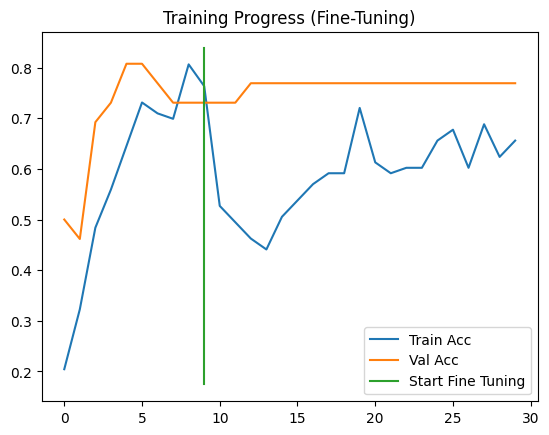

In [19]:
# Завантажуємо базову модель
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Будуємо модель
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'), # Додатковий шар для "розуму"
    layers.Dropout(0.5),                  # Більший Dropout, бо даних мало
    layers.Dense(len(class_names), activation='softmax')
])

base_model.trainable = False 

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Етап 1: Грубе навчання...")
history1 = model.fit(
    train_generator,
    epochs=10, # 10 епох для початку
    validation_data=validation_generator,
    verbose=1
)

base_model.trainable = True

# Заморожуємо перші 100 шарів, залишаємо останні ~50 для навчання
for layer in base_model.layers[:100]:
    layer.trainable = False

# Важливо: Дуже низький Learning Rate, щоб не зіпсувати ваги
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Точне до-навчання (Fine-Tuning)...")
history2 = model.fit(
    train_generator,
    epochs=20, # Ще 20 епох
    validation_data=validation_generator,
    verbose=1
)

# 3. Збереження
model.save('my_custom_face_model_tuned.h5')
print("Покращена модель збережена!")

# Об'єднання історії для графіку
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.plot([9, 9], plt.ylim(), label='Start Fine Tuning') # Лінія розділення етапів
plt.legend()
plt.title('Training Progress (Fine-Tuning)')
plt.show()

Класи: ['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling']


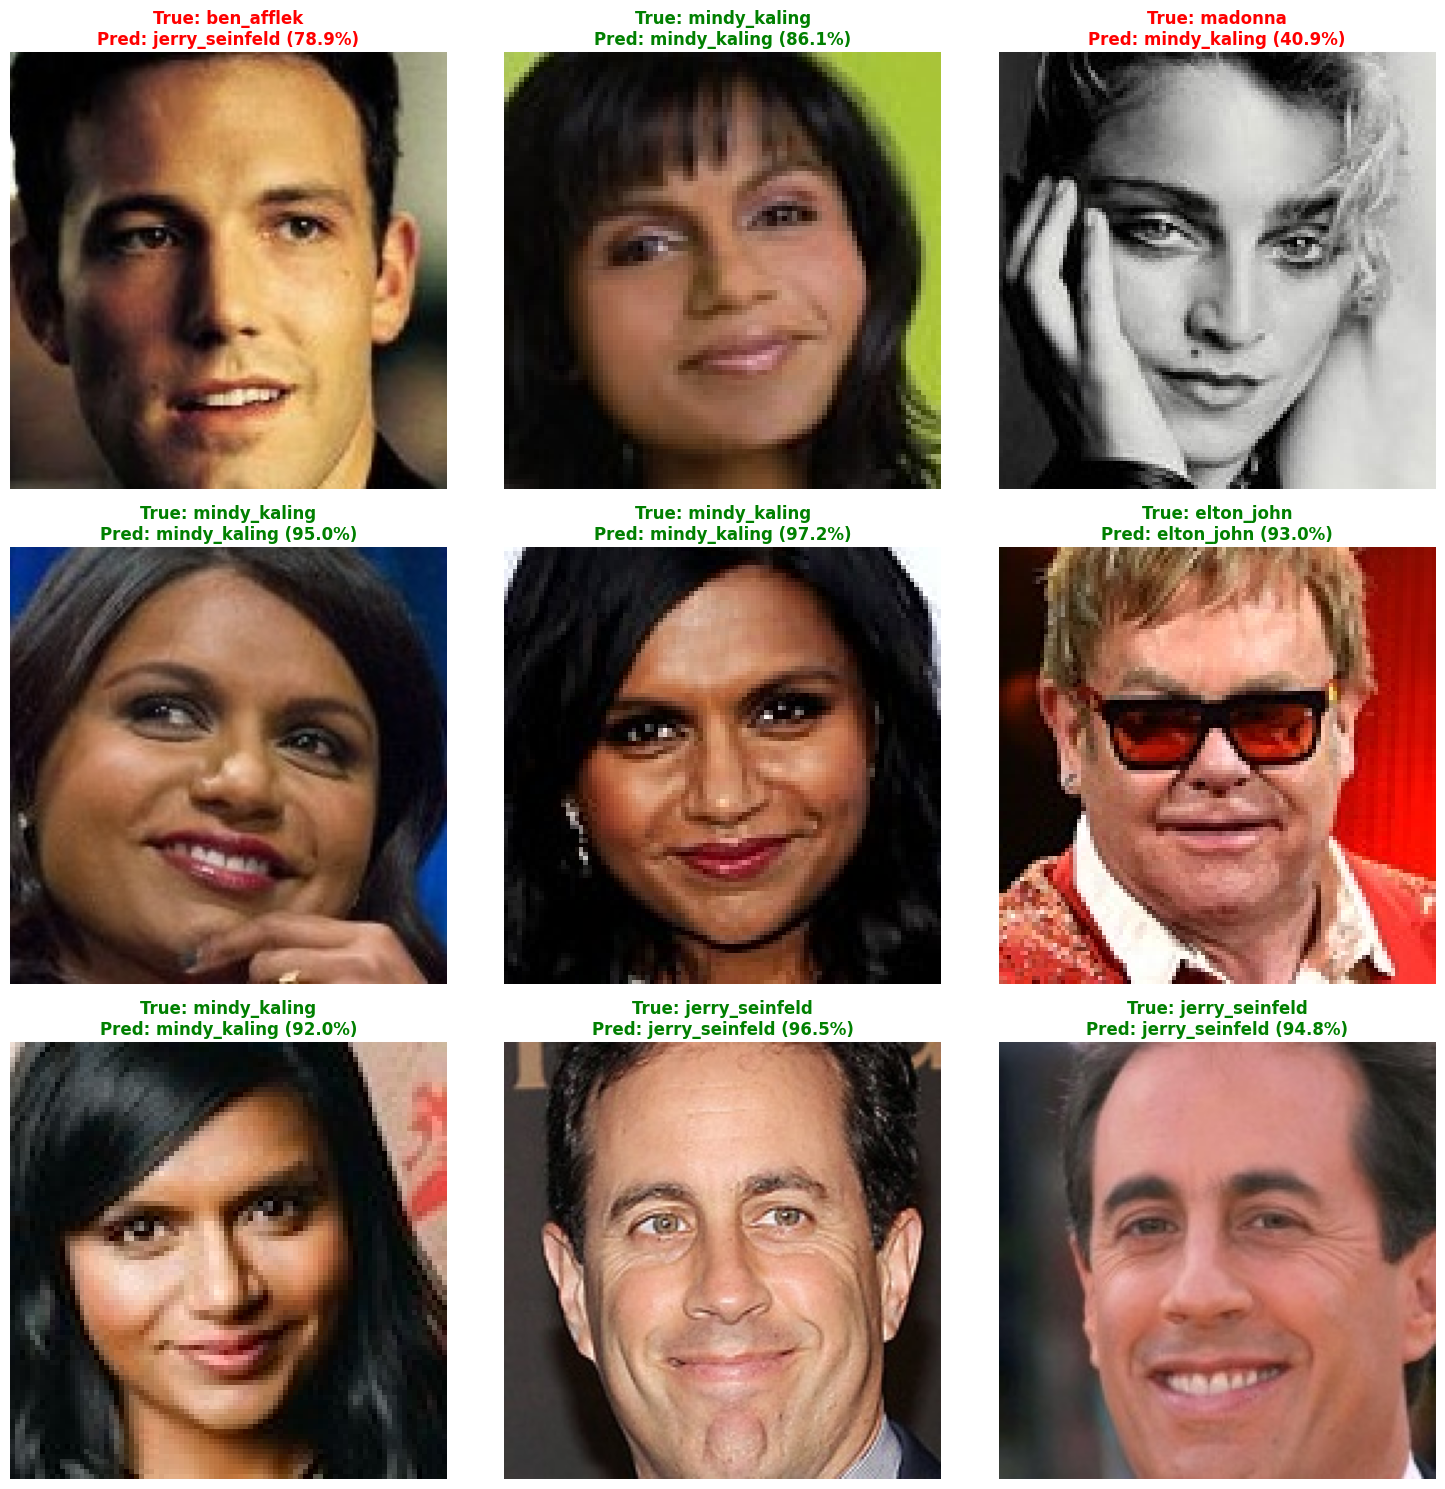

In [22]:
MODEL_PATH = 'my_custom_face_model_tuned.h5'
IMG_SIZE = 160
NUM_IMAGES = 9  # Кількість фото (3x3)
CROPPED_DIR = 'dataset_cropped' # Папка з вирізаними обличчями

# Завантаження моделі
if not os.path.exists(MODEL_PATH):
    print(f"Помилка: Не знайдено файл моделі {MODEL_PATH}. Спочатку запустіть Блок 4 (Навчання).")
else:
    model = load_model(MODEL_PATH)
    train_dir = os.path.join(CROPPED_DIR, 'train')
    if os.path.exists(train_dir):
    # Сортуємо, щоб порядок збігався з тим, як навчалася модель
        class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    print(f"Класи: {class_names}")

    # Вибір випадкових фото з валідації
    # Ми беремо фото прямо з папки вирізаних облич (dataset_cropped/val), 
    # бо модель вміє працювати тільки з ними
    val_dir = os.path.join(CROPPED_DIR, 'val')
    all_val_images = []
    
    if os.path.exists(val_dir):
        for root, dirs, files in os.walk(val_dir):
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_val_images.append(os.path.join(root, file))

    if len(all_val_images) == 0:
        print("Не знайдено зображень для тестування.")
    else:
        if len(all_val_images) < NUM_IMAGES:
            selected_images = all_val_images
        else:
            selected_images = random.sample(all_val_images, NUM_IMAGES)

        # Побудова сітки
        plt.figure(figsize=(15, 15))

        for i, img_path in enumerate(selected_images):
            # Отримуємо справжнє ім'я з назви папки
            true_label = os.path.basename(os.path.dirname(img_path))
            
            img = cv2.imread(img_path)
            if img is None: continue
            
            # Конвертуємо для моделі
            rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Preprocessing
            face_input = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))
            face_input = np.expand_dims(face_input, axis=0)
            face_input = preprocess_input(face_input)
            
            # --- ПЕРЕДБАЧЕННЯ ---
            preds = model.predict(face_input, verbose=0)
            idx = np.argmax(preds)
            confidence = np.max(preds) * 100
            
            if idx < len(class_names):
                pred_label = class_names[idx]
            else:
                pred_label = "Error"
            
            # --- ЛОГІКА КОЛЬОРІВ ---
            if pred_label == true_label:
                color = (0, 255, 0) # Green
                title_color = 'green'
            else:
                color = (255, 0, 0) # Red
                title_color = 'red'
                
            # Додаємо в сітку
            plt.subplot(3, 3, i + 1)
            plt.imshow(rgb_img)
            plt.axis('off')
            
            # Підпис
            title_text = f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
            plt.title(title_text, fontsize=12, fontweight='bold', color=title_color)

        plt.tight_layout()
        plt.show()